<a href="https://colab.research.google.com/github/tawsif113/ml-python-foundations/blob/main/week1/Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load and inspect dataset

In [63]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

titanic_df = sns.load_dataset("titanic")
print(titanic_df.head())
print(titanic_df.shape)
print(titanic_df.columns)
print(titanic_df.info())
print(titanic_df.describe())
print(titanic_df.describe(include="object"))

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
(891, 15)
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
<class 'pandas.core.

In [64]:
print(titanic_df.isnull().sum())
print(titanic_df.isnull().mean() * 100)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [65]:
print(titanic_df["survived"].value_counts())
print(titanic_df["sex"].value_counts())
print(titanic_df["class"].value_counts())
print(titanic_df["embarked"].value_counts())

survived
0    549
1    342
Name: count, dtype: int64
sex
male      577
female    314
Name: count, dtype: int64
class
Third     491
First     216
Second    184
Name: count, dtype: int64
embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [66]:
print(titanic_df.groupby("sex")["survived"].mean())
print(titanic_df.groupby("class")["survived"].mean())

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64


/tmp/ipykernel_197/128532268.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(titanic_df.groupby("class")["survived"].mean())


Visualization basics

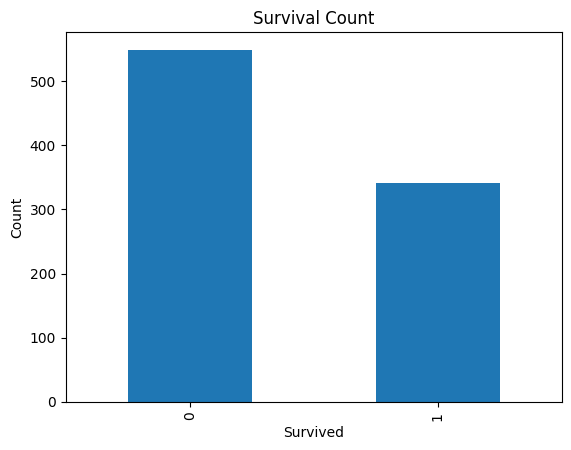

In [67]:
titanic_df["survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

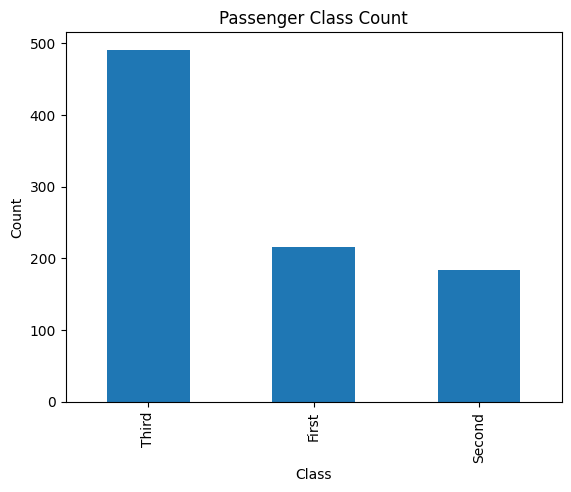

In [68]:
titanic_df["class"].value_counts().plot(kind="bar")
plt.title("Passenger Class Count")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

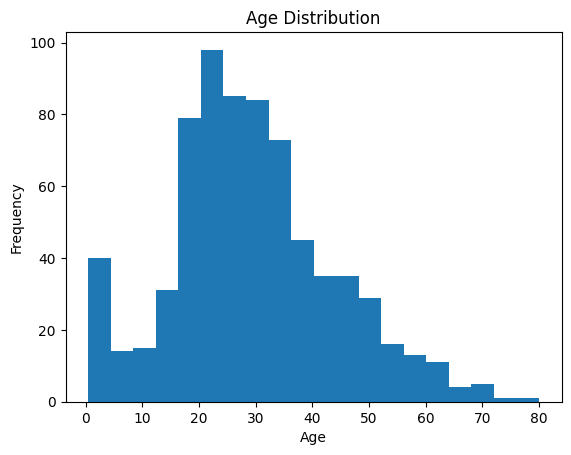

In [69]:
titanic_df["age"].plot(kind="hist", bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

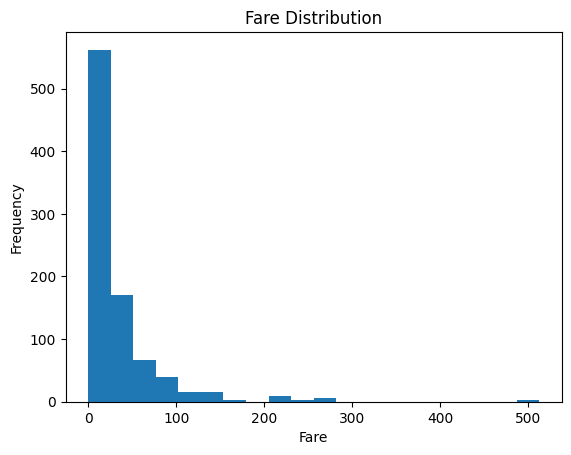

In [70]:
titanic_df["fare"].plot(kind="hist", bins=20)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

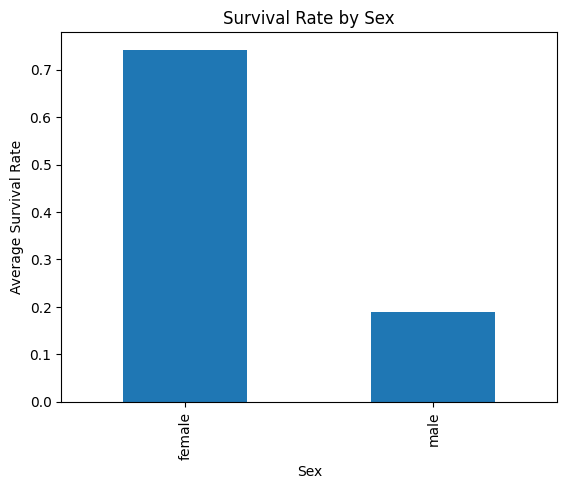

In [71]:
titanic_df.groupby("sex")["survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Survival Rate")
plt.show()

In [72]:
cleaned_df = titanic_df.drop(columns=["deck"])

In [73]:
cleaned_df["age"] = cleaned_df["age"].fillna(cleaned_df["age"].median())

In [74]:
cleaned_df["embark_town"] = cleaned_df["embark_town"].fillna(cleaned_df["embark_town"].mode()[0])

In [76]:
cleaned_df["embarked"] = cleaned_df["embarked"].fillna(cleaned_df["embarked"].mode()[0])

In [77]:
print(cleaned_df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [78]:
print(cleaned_df[cleaned_df["age"] > 30].head())
print(cleaned_df[cleaned_df["fare"] > 50].head())
print(cleaned_df[(cleaned_df["sex"] == "female") & (cleaned_df["survived"] == 1)].head())

    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
1          1       1  female  38.0      1      0  71.2833        C  First   
3          1       1  female  35.0      1      0  53.1000        S  First   
4          0       3    male  35.0      0      0   8.0500        S  Third   
6          0       1    male  54.0      0      0  51.8625        S  First   
11         1       1  female  58.0      0      0  26.5500        S  First   

      who  adult_male  embark_town alive  alone  
1   woman       False    Cherbourg   yes  False  
3   woman       False  Southampton   yes  False  
4     man        True  Southampton    no   True  
6     man        True  Southampton    no   True  
11  woman       False  Southampton   yes   True  
    survived  pclass     sex   age  sibsp  parch      fare embarked  class  \
1          1       1  female  38.0      1      0   71.2833        C  First   
3          1       1  female  35.0      1      0   53.1000        S  First   
6  

In [79]:
print(cleaned_df.groupby("pclass")["fare"].mean())
print(cleaned_df.groupby("sex")["age"].mean())
print(cleaned_df.groupby(["sex", "class"])["survived"].mean())

pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64
sex
female    27.929936
male      30.140676
Name: age, dtype: float64
sex     class 
female  First     0.968085
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64


/tmp/ipykernel_197/1653902475.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(cleaned_df.groupby(["sex", "class"])["survived"].mean())


Practice Task

In [81]:
print(titanic_df.shape[0])
print(titanic_df.shape[1])
print(titanic_df.columns)

891
15
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [94]:
null_df = titanic_df.isnull().sum()
print(null_df.sort_values(ascending=False))

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64


In [98]:
group_by_pc = titanic_df.groupby("pclass")["fare"].mean()
print(group_by_pc)
print(group_by_pc[1])

pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64
84.1546875


In [105]:
print(titanic_df.groupby("sex")["survived"].mean())

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
